# pyFracAggregate — Comprehensive Demo

This notebook demonstrates the full capabilities of **pyFracAggregate**, a Python library for generating and analyzing fractal aggregates.

**Contents:**
1. [Introduction & Setup](#Introduction-&-Setup)
2. [Core Workflow — End-to-End](#Core-Workflow)
3. [Generation Methods — Comparing Four Algorithms](#Generation-Methods)
4. [Analysis & Visualization — Morphology and Fractal Dimension](#Analysis-&-Visualization)
5. [Export & Rendering — Format Details](#Export-&-Rendering)

In [1]:
import pyFracAggregate as pfa
import numpy as np
import os

print(f"pyFracAggregate version: {pfa.__version__}")

# Check optional visualization dependencies
try:
    import pyvista
    print(f"pyvista {pyvista.__version__} — 3D rendering available")
except ImportError:
    print("pyvista not installed — 3D rendering (export_render, export_rotation_video) will not work")

try:
    import imageio
    print(f"imageio {imageio.__version__} — video export available")
except ImportError:
    print("imageio not installed — export_rotation_video will not work")

pyFracAggregate version: 0.4.0
pyvista 0.47.3 — 3D rendering available
imageio 2.37.2 — video export available


---

## Core Workflow — End-to-End

This section walks through the complete pipeline: **generate → analyze → export**. By the end, you'll have a full set of output files from a single PCA aggregate.

In [2]:
# Generate a fractal aggregate using Particle-Cluster Aggregation (PCA)
agg = pfa.generate(
    n_particles=100,
    df=1.8,       # Fractal dimension
    kf=1.2,       # Fractal prefactor
    method='pca',
    seed=0
)

print(f"Particles: {agg.current_size}")
print(f"Radius range: [{agg.radii.min():.3f}, {agg.radii.max():.3f}]")
print(f"Position bounds: x[{agg.positions[:,0].min():.1f}, {agg.positions[:,0].max():.1f}]"
      f" y[{agg.positions[:,1].min():.1f}, {agg.positions[:,1].max():.1f}]"
      f" z[{agg.positions[:,2].min():.1f}, {agg.positions[:,2].max():.1f}]")

Particles: 100
Radius range: [1.000, 1.000]
Position bounds: x[-14.6, 3.8] y[-17.0, 16.4] z[-13.0, 2.4]


In [3]:
# Analyze morphological properties (returns a MorphologyReport)
results = pfa.analyze(agg)

print("Analysis Results:")
print(f"  Number of particles (N): {results.n}")
print(f"  Radius of gyration (Rg): {results.rg:.2f}")
print(f"  Center of mass (CoM):    [{results.com[0]:.2f}, {results.com[1]:.2f}, {results.com[2]:.2f}]")
print(f"  Estimated Df:            {results.df_est:.2f} (input: 1.80)")
print(f"  Fit quality (R2):        {results.r2:.4f}")


Analysis Results:
  Number of particles (N): 100
  Radius of gyration (Rg): 11.65
  Center of mass (CoM):    [-3.88, -0.20, -6.36]
  Estimated Df:            1.31 (input: 1.80)
  Fit quality (R2):        0.9802


In [4]:
os.makedirs("output", exist_ok=True)

# Export to YAML — full snapshot with metadata
pfa.export_yaml(
    agg, "output/aggregate.yaml",
    generation_params={"method": "pca", "n_particles": 100, "df": 1.8, "kf": 1.2},
    analysis_results=results,
)
print("\u2713 YAML exported")

# Export to VTK — point cloud
pfa.export_vtk(agg, "output/points.vtk")
print("\u2713 VTK point cloud exported")

# Export to VTM — MultiBlock (spheres as structured data)
pfa.export_vtm(agg, "output/blocks.vtm")
print("\u2713 VTM MultiBlock exported")

✓ YAML exported
✓ VTK point cloud exported


✓ VTM MultiBlock exported


In [5]:
# Render a 3D screenshot
pfa.export_render(agg, "output/aggregate_render.png", camera_position="iso")
print("\u2713 Rendered PNG saved")

# Generate a 360\u00b0 rotation video
pfa.export_rotation_video(agg, "output/aggregate_rotation.mp4", n_frames=72, fps=24)
print("\u2713 Rotation video saved")

print("\nAll exports complete. Check the 'output' directory.")

2026-09-04 14:47:56.692 (   3.176s) [    7F6CF888F740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=
libEGL warning: failed to open /dev/dri/renderD129: Permission denied

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

2026-09-04 14:47:56.762 (   3.245s) [    7F6CF888F740]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

2026-09-04 14:47:56.883 (   3.367s) [    7F6CF888F740]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permiss

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

2026-09-04 14:47:57.489 (   3.972s) [    7F6CF888F740]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied



✓ Rendered PNG saved


libEGL warning: failed to open /dev/dri/renderD129: Permission denied

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

2026-09-04 14:47:58.477 (   4.960s) [    7F6CF888F740]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

2026-09-04 14:47:58.542 (   5.025s) [    7F6CF888F740]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

libEGL warning: failed to open /dev/dri/r

✓ Rotation video saved

All exports complete. Check the 'output' directory.


**Core workflow complete.** You generated a PCA aggregate, analyzed its morphological properties, and exported it in three data formats (YAML, VTK, VTM) and two visual formats (PNG render, MP4 rotation video). New users can stop here — the following sections explore the full API in more detail.

---
## Generation coordinates — the three-axis system

pyFracAggregate selects algorithms on three orthogonal axes
(`method` × `scaling` × `placement`); the classical methods are coordinates:

| Literature method | Coordinate |
|---|---|
| DLA-style PCA | `(pca, count, solved)` |
| Filippov CCA (2000) | `(cca, count, sampled)` |
| FLAGE-style CCA (Skorupski 2014) | `(cca, count, solved)` |
| FracVAL (Morán 2019) | `(cca, mass, constructed)` |

`'fracval'` is a deprecated alias for `(cca, mass, constructed)`;
`'tdcca'` was removed in v0.4.


In [6]:
# Compare generation coordinates with the same fractal parameters
coords = {
    'pca':      dict(method='pca'),
    'cca':      dict(method='cca'),
    'fracval':  dict(method='cca', scaling='mass', placement='constructed'),
}
aggregates = {}

for name, kw in coords.items():
    print(f"Generating {name} ({kw})...")
    aggregates[name] = pfa.generate(n_particles=50, df=1.8, kf=1.2, seed=0, **kw)

print("\n--- Comparison ---")
print(f"{'Coordinate':<12} {'N':>5} {'Rg':>8}")
print("-" * 28)
for name, agg_m in aggregates.items():
    rg = pfa.radius_of_gyration(agg_m)
    print(f"{name:<12} {agg_m.current_size:>5} {rg:>8.2f}")


Generating pca ({'method': 'pca'})...


Generating cca ({'method': 'cca'})...


Generating fracval ({'method': 'cca', 'scaling': 'mass', 'placement': 'constructed'})...



--- Comparison ---
Coordinate       N       Rg
----------------------------
pca             50     7.92
cca             50     7.94
fracval         50     7.94


### Placement Strategies

Three placement strategies control how particles are positioned during
generation:

- **`'solved'`** (default) — closed-form touching-point computation with
  Monte Carlo fallback. More accurate and faster.
- **`'sampled'`** — pure Monte Carlo sampling.
- **`'constructed'`** — FracVAL contact-pair construction (merge-only).

`'algebraic'` (→ `'solved'`) and `'random'` (→ `'sampled'`) are deprecated
aliases, removed in 1.0.


In [7]:
# Compare placement strategies ('algebraic'/'random' are deprecated aliases)
for placement in ['solved', 'sampled']:
    agg_p = pfa.generate(n_particles=50, df=1.8, kf=1.2, method='pca',
                         placement=placement, seed=0)
    rg = pfa.radius_of_gyration(agg_p)
    print(f"placement={placement:<10} → N={agg_p.current_size}, Rg={rg:.2f}")


placement=solved     → N=50, Rg=7.92


placement=sampled    → N=50, Rg=7.92


### Particle Distributions

By default, particles have uniform radius (`Monodisperse`). You can also use a `LognormalDistribution` for polydisperse systems:

In [8]:
# Monodisperse vs Lognormal distribution (std is the GEOMETRIC std; > 1.0)
mono = pfa.Monodisperse(radius=1.0)
lognorm = pfa.LognormalDistribution(mean=1.0, std=1.6)

for name, dist in [("Monodisperse(1.0)", mono), ("Lognormal(1.0, 1.6)", lognorm)]:
    agg_d = pfa.generate(n_particles=50, df=1.8, kf=1.2, method='pca',
                         particle_dist=dist, seed=0)
    print(f"{name:<25} → N={agg_d.current_size}, Rg={pfa.radius_of_gyration(agg_d):.2f}")
    print(f"  Radii: min={agg_d.radii.min():.3f}, max={agg_d.radii.max():.3f}, mean={agg_d.radii.mean():.3f}")


Monodisperse(1.0)         → N=50, Rg=7.92
  Radii: min=1.000, max=1.000, mean=1.000


Lognormal(1.0, 1.6)       → N=50, Rg=14.06
  Radii: min=0.335, max=2.513, mean=1.163


**Method selection guide:**
- **PCA** — Good baseline, fast for small-to-medium aggregates.
- **CCA** — Better for larger aggregates with natural cluster structure.
- **FracVAL** — When you need precise control over the fractal dimension.
- **TDCCA** — For strict fractal scaling with cluster-cluster accuracy.

---

## Analysis & Visualization — Morphology and Fractal Dimension

This section takes a deeper look at aggregate analysis: morphological properties, the pair correlation function (PCF), and fractal dimension estimation.

In [9]:
# Generate a larger aggregate for better statistical analysis
agg_large = pfa.generate(n_particles=500, df=1.8, kf=1.2, method='pca')
print(f"Generated: N={agg_large.current_size}")

Generated: N=500


In [10]:
# Morphological analysis
rg = pfa.radius_of_gyration(agg_large)
com = pfa.center_of_mass(agg_large)

print(f"Radius of gyration (Rg): {rg:.2f}")
print(f"Center of mass (CoM):    [{com[0]:.2f}, {com[1]:.2f}, {com[2]:.2f}]")

Radius of gyration (Rg): 28.53
Center of mass (CoM):    [-3.22, -17.02, -1.58]


In [11]:
# Pair correlation function and fractal dimension estimation
r_centers, c_r = pfa.pair_correlation_function(agg_large, bins=100)
df_est, r2, fit_info = pfa.estimate_fractal_dimension(
    r_centers, c_r,
    r_min=np.mean(agg_large.radii),
    r_max=rg,
)

print("Input Df:         1.80")
print(f"Estimated Df:     {df_est:.2f}")
print(f"Fit R²:           {r2:.4f}")
print(f"Fit range:        r ∈ [{fit_info.get('r_min', 'N/A'):.2f}, {fit_info.get('r_max', 'N/A'):.2f}]")

Input Df:         1.80
Estimated Df:     1.17
Fit R²:           0.9735
Fit range:        r ∈ [2.07, 27.77]


Plot saved to output/pcf_analysis.png
PCF plot saved to output/pcf_analysis.png


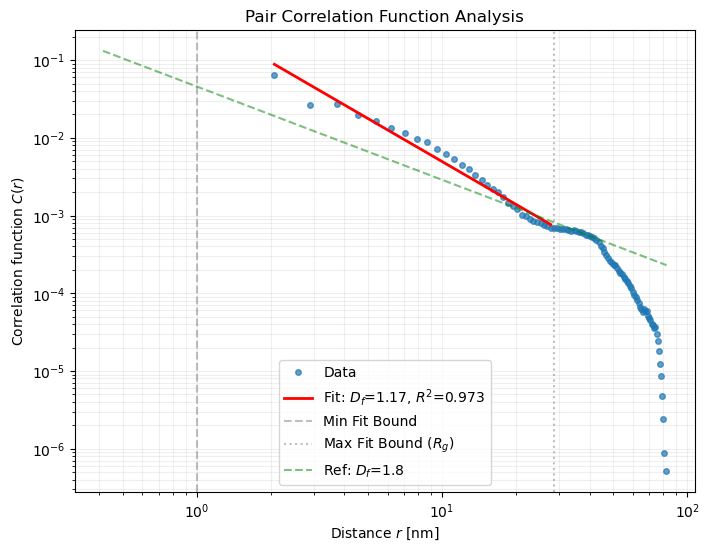

In [12]:
# Plot the pair correlation function with fractal fit
pfa.plot_pair_correlation(
    agg_large,
    bins=100,
    show_fit=True,
    reference_df=1.8,
    save_path="output/pcf_analysis.png",
)
print("PCF plot saved to output/pcf_analysis.png")

The PCF plot shows:
- **Blue dots**: Measured pair correlation function C(r)
- **Red dashed line**: Power-law fit in the fractal regime — slope = Df − 3
- **Green dotted line**: Reference slope for the input Df

A good fit (R² > 0.95) confirms the aggregate exhibits the expected fractal scaling.

---

## Export & Rendering — Format Details

pyFracAggregate supports five export formats:

| Format | Function | Description |
|--------|----------|-------------|
| YAML | `export_yaml()` | Full snapshot: data + generation params + analysis results |
| VTK | `export_vtk()` | Point cloud — positions and radii as scalar field |
| VTM | `export_vtm()` | MultiBlock dataset — spheres as structured mesh blocks |
| PNG | `export_render()` | 3D rendered screenshot with configurable camera |
| MP4 | `export_rotation_video()` | 360° rotation animation |

In [13]:
# YAML export — full snapshot with metadata
pfa.export_yaml(
    agg_large, "output/full_aggregate.yaml",
    generation_params={"method": "pca", "n_particles": 500, "df": 1.8, "kf": 1.2},
    analysis_results=pfa.analyze(agg_large),
)

# Read back and inspect structure
import yaml  # noqa: E402
with open("output/full_aggregate.yaml") as f:
    data = yaml.safe_load(f)

print("YAML top-level keys:", list(data.keys()))
print(f"  Particles: {len(data['aggregate']['positions'])}")
if 'generation' in data:
    print(f"  Generation params: {data['generation']}")
if 'analysis' in data:
    print(f"  Analysis keys: {list(data['analysis'].keys())}")

YAML top-level keys: ['generation', 'aggregate', 'analysis']
  Particles: 500
  Generation params: {'method': 'pca', 'n_particles': 500, 'df': 1.8, 'kf': 1.2}
  Analysis keys: ['Rg', 'CoM', 'N', 'Df_estimated', 'R2', 'r_centers', 'pair_correlation']


In [14]:
# VTK and VTM export — compare file sizes
pfa.export_vtk(agg_large, "output/points_500.vtk")
pfa.export_vtm(agg_large, "output/blocks_500.vtm")

vtk_size = os.path.getsize("output/points_500.vtk")
vtm_size = os.path.getsize("output/blocks_500.vtm")

print(f"VTK (point cloud): {vtk_size / 1024:.1f} KB")
print(f"VTM (MultiBlock):  {vtm_size / 1024:.1f} KB")

VTK (point cloud): 27.6 KB
VTM (MultiBlock):  39.5 KB


In [15]:
# Multi-angle rendering with different camera positions
cameras = {
    'iso': 'Isometric (default)',
    'xy': 'XY plane — top-down view',
    'xz': 'XZ plane — side view',
}

for cam, desc in cameras.items():
    path = f"output/render_{cam}.png"
    pfa.export_render(agg_large, path, camera_position=cam)
    print(f"  {cam}: {desc} → {path}")

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

2026-09-04 14:48:43.088 (  49.571s) [    7F6CF888F740]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

2026-09-04 14:48:43.176 (  49.659s) [    7F6CF888F740]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied



libEGL warning: failed to open /dev/dri/renderD129: Permission denied

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

2026-09-04 14:48:46.709 (  53.193s) [    7F6CF888F740]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied



  iso: Isometric (default) → output/render_iso.png


libEGL warning: failed to open /dev/dri/renderD129: Permission denied

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

2026-09-04 14:48:47.301 (  53.784s) [    7F6CF888F740]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

2026-09-04 14:48:47.319 (  53.803s) [    7F6CF888F740]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied



libEGL warning: failed to open /dev/dri/renderD129: Permission denied

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

2026-09-04 14:48:49.759 (  56.242s) [    7F6CF888F740]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied



  xy: XY plane — top-down view → output/render_xy.png


libEGL warning: failed to open /dev/dri/renderD129: Permission denied

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

2026-09-04 14:48:50.953 (  57.436s) [    7F6CF888F740]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

2026-09-04 14:48:51.070 (  57.553s) [    7F6CF888F740]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied



libEGL warning: failed to open /dev/dri/renderD129: Permission denied

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

2026-09-04 14:48:56.742 (  63.226s) [    7F6CF888F740]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied



  xz: XZ plane — side view → output/render_xz.png


In [16]:
# Custom rotation video — higher quality settings
pfa.export_rotation_video(
    agg_large,
    "output/aggregate_rotation_hq.mp4",
    n_frames=120,
    fps=30,
    elevation=20,
)
print("High-quality rotation video saved (120 frames, 30 fps, elevation=20°)")

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

2026-09-04 14:49:01.443 (  67.926s) [    7F6CF888F740]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

2026-09-04 14:49:01.488 (  67.971s) [    7F6CF888F740]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD129: Permission denied

libEGL warning: failed to open /dev/dri/r

High-quality rotation video saved (120 frames, 30 fps, elevation=20°)


### Export Format Selection Guide

- **YAML** — For reproducibility: store the complete state to reload later.
- **VTK** — For lightweight point cloud visualization in ParaView or similar tools.
- **VTM** — For full 3D sphere representation (larger files, richer visualization).
- **PNG** — For static figures in papers and presentations.
- **MP4** — For supplementary materials and presentations.

**Tip:** Use VTK for quick inspection and VTM when you need actual sphere geometries.